In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('customer_churn.csv',delimiter=';')

In [3]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
440827,449995,42,Male,54.0,15,1.0,3,Premium,Annual,716.38,8,0
440828,449996,25,Female,8.0,13,1.0,20,Premium,Annual,745.38,2,0
440829,449997,26,Male,35.0,27,1.0,5,Standard,Quarterly,977.31,9,0
440830,449998,28,Male,55.0,14,2.0,0,Standard,Quarterly,602.55,2,0
440831,449999,31,Male,48.0,20,1.0,14,Premium,Quarterly,567.77,21,0


In [4]:
df.shape

(440832, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  int64  
 1   Age                440832 non-null  int64  
 2   Gender             440821 non-null  object 
 3   Tenure             440820 non-null  float64
 4   Usage Frequency    440832 non-null  int64  
 5   Support Calls      440802 non-null  float64
 6   Payment Delay      440832 non-null  int64  
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440823 non-null  float64
 10  Last Interaction   440832 non-null  int64  
 11  Churn              440832 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 40.4+ MB


In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [7]:
df=df.rename(columns={"Usage Frequency": "UsageFrequency", "Support Calls": "SupportCalls", 
                   "Payment Delay": "PaymentDelay","Subscription Type":"SubscriptionType",
                   "Contract Length": "ContractLength" , "Total Spend":  "TotalSpend", 
                   "Last Interaction":"LastInteraction" })

In [8]:
df.Churn.value_counts()

Churn
1    249999
0    190833
Name: count, dtype: int64

**Split Data into Train and Test Data**

In [9]:
input_df=df.drop(['Churn','CustomerID'],axis=1)
output_df=df['Churn']

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_df, output_df, test_size = 0.2, random_state = 42,stratify=output_df)

In [11]:
x_train.head()

,Age,Gender,Tenure,UsageFrequency,SupportCalls,PaymentDelay,SubscriptionType,ContractLength,TotalSpend,LastInteraction
318330,42,Male,46.0,30,3.0,4,Standard,Annual,945.08,8
429061,33,Female,43.0,17,1.0,15,Standard,Annual,987.79,12
60074,26,Female,13.0,30,4.0,12,Premium,Quarterly,800.00,5
12759,29,Female,9.0,23,10.0,24,Basic,Quarterly,119.00,19
357320,38,Male,10.0,20,0.0,0,Basic,Annual,678.97,18


In [12]:
y_train.head()

318330    0
429061    0
60074     1
12759     1
357320    0
Name: Churn, dtype: int64

In [13]:
x_train.columns

Index(['Age', 'Gender', 'Tenure', 'UsageFrequency', 'SupportCalls',
       'PaymentDelay', 'SubscriptionType', 'ContractLength', 'TotalSpend',
       'LastInteraction'],
      dtype='object')

In [14]:
x_train.shape

(352665, 10)

In [15]:
#identify numerical and categorical features
cat_feat = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_feat = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [16]:
num_feat

['Age',
 'Tenure',
 'UsageFrequency',
 'SupportCalls',
 'PaymentDelay',
 'TotalSpend',
 'LastInteraction']

In [17]:
cat_feat

['Gender', 'SubscriptionType', 'ContractLength']

**Handle Missing Value**

In [18]:
#create variable with or without outlier if it is needed. in this case all numerical variable are outliers free
#without_out_num=x_train[['Tenure','Support Calls','Total Spend']]
#with_out_num=x_train[['Tenure','Support Calls','Total Spend']]

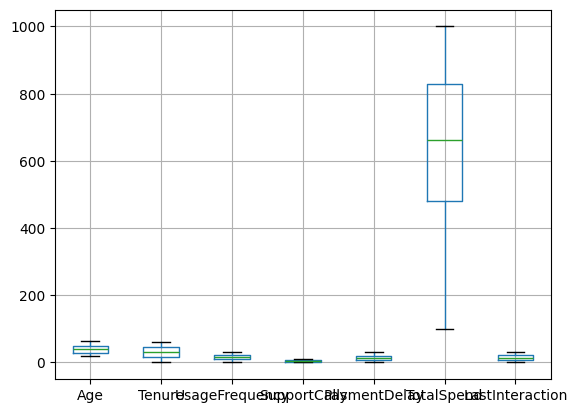

In [19]:
#Check Outliers
boxplot = x_train.boxplot(column=num_feat)
plt.show()

**Create Preprocessing Pipeline**
1. Impute missing value for numeric and categorical features
2. Encode categorical features

In [20]:
x_train['Gender'].value_counts()

Gender
Male      200308
Female    152347
Name: count, dtype: int64

In [21]:
x_train['SubscriptionType'].value_counts()

SubscriptionType
Standard    119309
Premium     118824
Basic       114532
Name: count, dtype: int64

In [22]:
x_train['ContractLength'].value_counts()

ContractLength
Annual       141539
Quarterly    141288
Monthly       69838
Name: count, dtype: int64

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

#for impute missing value numerical features and categorical
numeric_preprocess = Pipeline([('num_imputer', SimpleImputer(strategy='mean'))])

categorical_preprocess= Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
                                  ('cat_encoder', OrdinalEncoder(categories=[['Male', 'Female'],
                                                                            ['Basic', 'Standard', 'Premium'],
                                                                            ['Monthly','Quarterly','Annual']]))])
                                  

**Combine all preprocess step**

In [24]:
from sklearn.compose import ColumnTransformer
preprocess=ColumnTransformer(transformers=[
    ('numPreprocess', numeric_preprocess, num_feat),
    ('catPreprocess', categorical_preprocess,(['Gender','SubscriptionType','ContractLength']))
    ],
    remainder='drop')

In [25]:
preprocess

,transformers,"[('numPreprocess', ...), ('catPreprocess', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [26]:
x_train_preprocess=preprocess.fit_transform(x_train)

In [27]:
x_train.shape

(352665, 10)

In [28]:
x_train.iloc[0:2]

,Age,Gender,Tenure,UsageFrequency,SupportCalls,PaymentDelay,SubscriptionType,ContractLength,TotalSpend,LastInteraction
318330,42,Male,46.0,30,3.0,4,Standard,Annual,945.08,8
429061,33,Female,43.0,17,1.0,15,Standard,Annual,987.79,12


In [29]:
x_train_preprocess.shape

(352665, 10)

In [30]:
x_train_preprocess[0:2,:]

array([[ 42.  ,  46.  ,  30.  ,   3.  ,   4.  , 945.08,   8.  ,   0.  ,
          1.  ,   2.  ],
       [ 33.  ,  43.  ,  17.  ,   1.  ,  15.  , 987.79,  12.  ,   1.  ,
          1.  ,   2.  ]])

**Complete pipeline for preprocessing and model**

In [31]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

churn_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(criterion= 'gini',max_depth=4))])

**Train the pipeline**

In [32]:
churn_pred.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numPreprocess', ...), ('catPreprocess', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_predict=churn_pred.predict(x_test)

In [34]:
from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(y_test, y_predict, target_names=['1','0']))


Classification Report

              precision    recall  f1-score   support

           1       0.95      0.99      0.97     38167
           0       0.99      0.96      0.98     50000

    accuracy                           0.97     88167
   macro avg       0.97      0.98      0.97     88167
weighted avg       0.98      0.97      0.98     88167

